# IMU Physical Activity Monitoring

##  Introduction

This project explores physical activity monitoring using data collected from Inertial Measurement Units (IMUs). The study is inspired by advancements in wearable technology and focuses on analyzing human activity through multi-sensor data.

The dataset is based on IMU devices equipped with sensors that measure acceleration, angular velocity, and magnetic field orientation. These sensors are typically positioned on different parts of the human body, such as the wrist, chest, and ankle, enabling comprehensive motion tracking. The dataset used in this project includes recordings from multiple individuals performing a variety of physical activities, ranging from basic movements to more complex actions.

In addition to motion data, heart rate measurements are incorporated to provide deeper insights into physiological responses during different activities. This combination of motion and biometric data allows for more detailed analysis and improved activity recognition.

The primary objective of this project is to perform exploratory data analysis (EDA) and identify patterns in human activity using IMU and heart rate data. Furthermore, machine learning techniques can be applied to classify and predict different physical activities based on these sensor readings.

By leveraging data-driven insights, this project demonstrates how wearable sensor data can be used for activity recognition, health monitoring, and intelligent system development.


In [1]:
# import all the required libraries

import numpy as np                    # Numpy fornumerical operations
import pandas as pd                   # For the data manipulation and analysis 
from matplotlib import pyplot as plt  # For data visualisation
import math                           # Math library for mathematical functions
import scipy.stats as stats           # Scipy for statistical functions
%matplotlib inline                    
from sklearn.model_selection import train_test_split   # Split data for training and testing
import seaborn as sns                 # For statistical data visualisation
#%matplotlib inline
#from sklearn.model_selection import train_test_split
import sklearn.model_selection as cross_validation   # Import for cross validation

# Load the Required Data

In [2]:
# Load dataset file paths for all subjects
file_paths = ['Dataset/Protocol/subject101.dat',
              'Dataset/Protocol/subject102.dat',
              'Dataset/Protocol/subject103.dat',
              'Dataset/Protocol/subject104.dat',
              'Dataset/Protocol/subject105.dat',
              'Dataset/Protocol/subject106.dat',
              'Dataset/Protocol/subject107.dat',
              'Dataset/Protocol/subject108.dat',
              'Dataset/Protocol/subject109.dat' ]

In [3]:
# Create a list of subject IDs
subject_ID = [1,2,3,4,5,6,7,8,9] 

# Create a dictionary mapping activity IDs to activity names
activity_ID = {0: 'Transient',
              1: 'Lying',
              2: 'Sitting',
              3: 'Standing',
              4: 'Walking',
              5: 'Running',
              6: 'Cycling',
              7: 'Nordic walking',
              9: 'Watching TV',
              10: 'Computer work',
              11: 'Car driving',
              12: 'Ascending stairs',
              13: 'Descending stairs',
              16: 'Vacuum cleaning',
              17: 'Ironing',
              18: 'Folding laundry',
              19: 'House cleaning',
              20: 'Playing soccer',
              24: 'Rope jumping' }

# Create a list of column names for the dataset
col_names = ["timestamp", "activity_id","heart_rate"]

# Create lists defining columns for different IMU sensor locations
IMU_hand = ['hand_temperature', 
           'hand_acc16_1', 'hand_acc16_2', 'hand_acc16_3', 
           'hand_acc6_1', 'hand_acc6_2', 'hand_acc6_3', 
           'hand_gyro_1', 'hand_gyro_2', 'hand_gyro_3', 
           'hand_magne_1', 'hand_magne_2', 'hand_magne_3',
           'hand_orientation_1', 'hand_orientation_2', 'hand_orientation_3', 'hand_orientation_4']

IMU_chest = ['chest_temperature', 
           'chest_acc16_1', 'chest_acc16_2', 'chest_acc16_3', 
           'chest_acc6_1', 'chest_acc6_2', 'chest_acc6_3', 
           'chest_gyro_1', 'chest_gyro_2', 'chest_gyro_3', 
           'chest_magne_1', 'chest_magne_2', 'chest_magne_3',
           'chest_orientation_1', 'chest_orientation_2', 'chest_orientation_3', 'chest_orientation_4']

IMU_ankle = ['ankle_temperature', 
           'ankle_acc16_1', 'ankle_acc16_2', 'ankle_acc16_3', 
           'ankle_acc6_1', 'ankle_acc6_2', 'ankle_acc6_3', 
           'ankle_gyro_1', 'ankle_gyro_2', 'ankle_gyro_3', 
           'ankle_magne_1', 'ankle_magne_2', 'ankle_magne_3',
           'ankle_orientation_1', 'ankle_orientation_2', 'ankle_orientation_3', 'ankle_orientation_4']

# Combine all column names into a single list
columns = col_names + IMU_hand + IMU_chest + IMU_ankle  

In [4]:
# Initialise an empty DataFrame to store combined data
data = pd.DataFrame()

# Iterate through each dataset file and process data
for file in file_paths:
    # Read the data from file using regular expression separator
    df = pd.read_csv(file, sep = '\s+|\s+', engine = 'python')
    
    # Extract a substring from the file path to creare a new CSV filename  
    strfile = file[17:27]+'.csv'
    
    # Save the current dataframe to a new CSV file
    df.to_csv(strfile, index = None)
    
    # Read the saved CSV file into a new DataFrame
    prdf = pd.read_csv(strfile)
    
    # Set the column names for the new DataFrame
    prdf.columns = columns
    
    # Extract and assign subject ID from filepath to new DataFrame
    prdf['subject_id'] = int(file[-5])
    
    # Concatenate the current DataFrame with the main DataFrame
    data = pd.concat([data, prdf], ignore_index = True)

# Reset index of the resulting DataFrame
data.reset_index(drop = True, inplace = True)

I haven't taken the Optional data given by the data collector which includes the optional activities chosen by some of the subjects for keeping, as adding optional data may alter the data analysis time and those activities were done by few subjects only. 

# Understanding the data

In [5]:
# Display first few rows of the resulting DataFrame
data.head()

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject_id
0,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,1
1,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,1
2,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,1
3,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,1
4,8.43,0,NaN,30.0,2.29959,8.82929,3.54710,2.26132,8.65762,3.77788,...,-0.016024,0.001050,-60.2954,-38.8778,-58.3977,1.0,0.0,0.0,0.0,1


In [6]:
# Display number of rows and columns of the DataFrame
data.shape

(2872524, 55)

The dataset was initially explored to understand its structure, dimensions, and data types. The combined dataset consists of 2,872,524 rows and 55 columns, including an additional subject_id column introduced to track individual participants.

The dataset contains both numerical and categorical attributes, with the majority of features represented as floating-point values. Summary statistics reveal key characteristics such as average heart rate, activity distribution, and sensor measurements across different body locations.

This initial exploration provides a strong foundation for subsequent preprocessing and analysis.

In [7]:
# Diplsy information about the DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2872524 entries, 0 to 2872523
Data columns (total 55 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            float64
 1   activity_id          int64  
 2   heart_rate           float64
 3   hand_temperature     float64
 4   hand_acc16_1         float64
 5   hand_acc16_2         float64
 6   hand_acc16_3         float64
 7   hand_acc6_1          float64
 8   hand_acc6_2          float64
 9   hand_acc6_3          float64
 10  hand_gyro_1          float64
 11  hand_gyro_2          float64
 12  hand_gyro_3          float64
 13  hand_magne_1         float64
 14  hand_magne_2         float64
 15  hand_magne_3         float64
 16  hand_orientation_1   float64
 17  hand_orientation_2   float64
 18  hand_orientation_3   float64
 19  hand_orientation_4   float64
 20  chest_temperature    float64
 21  chest_acc16_1        float64
 22  chest_acc16_2        float64
 23  chest_acc16_3        float64
 24

The given data has columns with two data type, with 53 being float64 and 2 being int64.

In [8]:
# Display Various statistical measures for each numerical columns in the DataFrame
data.describe()

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject_id
count,2.872524e+06,2.872524e+06,262265.000000,2.859383e+06,2.859383e+06,2.859383e+06,2.859383e+06,2.859383e+06,2.859383e+06,2.859383e+06,...,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.860775e+06,2.872524e+06
mean,1.834360e+03,5.466260e+00,109.872522,3.265258e+01,-4.960792e+00,3.587753e+00,3.168421e+00,-4.889425e+00,3.584262e+00,3.349484e+00,...,-3.450123e-02,7.752174e-03,-3.272101e+01,1.593297e+00,1.689044e+01,3.986420e-01,2.154751e-02,3.091536e-01,-1.878806e-02,4.500476e+00
std,1.105686e+03,6.331336e+00,25.870048,1.844268e+00,5.985030e+00,6.277844e+00,3.843921e+00,5.992727e+00,6.055755e+00,3.840648e+00,...,5.966035e-01,1.842555e+00,1.887861e+01,2.161180e+01,2.030852e+01,3.034559e-01,5.691301e-01,3.237875e-01,4.731372e-01,2.367002e+00
min,5.650000e+00,0.000000e+00,57.000000,2.475000e+01,-1.453670e+02,-1.043010e+02,-1.014520e+02,-6.148950e+01,-6.186800e+01,-6.193470e+01,...,-1.812690e+01,-1.401960e+01,-1.728650e+02,-1.379080e+02,-1.092890e+02,1.521280e-06,-9.568760e-01,-8.768380e-01,-9.972810e-01,1.000000e+00
25%,8.931700e+02,0.000000e+00,90.000000,3.143750e+01,-9.028420e+00,1.290260e+00,9.685885e-01,-8.933265e+00,1.284680e+00,1.164040e+00,...,-8.267115e-02,-3.084625e-01,-4.289480e+01,-1.148540e+01,3.289345e+00,1.563440e-01,-5.839910e-01,1.087100e-02,-5.047580e-01,2.000000e+00
50%,1.790830e+03,3.000000e+00,108.000000,3.312500e+01,-5.788150e+00,3.570830e+00,2.958420e+00,-5.737630e+00,3.613430e+00,3.132860e+00,...,-4.249850e-03,-2.215990e-03,-3.390020e+01,1.362640e+00,1.809110e+01,3.197560e-01,0.000000e+00,3.043840e-01,0.000000e+00,5.000000e+00
75%,2.710570e+03,7.000000e+00,125.000000,3.400000e+01,-7.829750e-01,6.602720e+00,6.002930e+00,-7.250000e-01,6.601955e+00,6.257615e+00,...,8.296965e-02,6.343350e-02,-1.905920e+01,1.733090e+01,3.087815e+01,5.794420e-01,6.279440e-01,6.020035e-01,4.634425e-01,7.000000e+00
max,4.475630e+03,2.400000e+01,202.000000,3.550000e+01,6.285960e+01,1.556990e+02,1.577600e+02,5.282140e+01,6.225980e+01,6.194460e+01,...,1.358820e+01,1.652880e+01,9.752550e+01,1.233060e+02,1.469000e+02,1.000000e+00,9.595380e-01,9.923540e-01,9.961050e-01,9.000000e+00


The summary statistics offer a thorough glimpse into the combined dataset, which includes data from all 55 attributes. The mean timestamp suggests that, on average, readings were taken over a period of 1834 seconds. The average activity_ID highlights a diverse range of activities carried out by individuals. Averaging at 109.87 bpm (beats per minute), the average heart rate showcases fluctuations in physiological reactions. Futhermore, the mean hand temperature of 32.65 degrees Celcius reveals the average temperature experienced during activities.

# Data Cleaning and Preprocessing
## a. Finding missing values

In [9]:
# Check the number of missing values in each column of the DataFrame
data.isnull().sum()

timestamp                    0
activity_id                  0
heart_rate             2610259
hand_temperature         13141
hand_acc16_1             13141
hand_acc16_2             13141
hand_acc16_3             13141
hand_acc6_1              13141
hand_acc6_2              13141
hand_acc6_3              13141
hand_gyro_1              13141
hand_gyro_2              13141
hand_gyro_3              13141
hand_magne_1             13141
hand_magne_2             13141
hand_magne_3             13141
hand_orientation_1       13141
hand_orientation_2       13141
hand_orientation_3       13141
hand_orientation_4       13141
chest_temperature         3563
chest_acc16_1             3563
chest_acc16_2             3563
chest_acc16_3             3563
chest_acc6_1              3563
chest_acc6_2              3563
chest_acc6_3              3563
chest_gyro_1              3563
chest_gyro_2              3563
chest_gyro_3              3563
chest_magne_1             3563
chest_magne_2             3563
chest_ma

In the given dataset, majority of the missing values are for the column 'heart_rate' with a count of 2610259 NaN values. The reason is, due to the 100Hz sampling frequency of Inertial Meassurement Units(IMUs), the data is recorded every 0.01 seconds. However, the Heart Rate Monitor has a lower sampling frequency of approximately 9Hz, causing some Heart Rate values to be missing. These missing values are accurately denoted as NaN in the dataset. So, from the dataset, I'm going to remove all the NaN values corresponding to the column 'heart_rate'.

In [10]:
# Remove rows with missing heart rate values due to lower sampling frequency
# Convert 'heart_rate' column to numeric, coercing errors to NaN
data['heart_rate'] = pd.to_numeric(data['heart_rate'], errors = 'coerce')

# Check for null values after cleaning
new_data = data.dropna(subset = ['heart_rate'])
null_values_after_cleaning = new_data.isnull().sum()

print("Null Values After Cleaning:")
print(null_values_after_cleaning)

Null Values After Cleaning:
timestamp                 0
activity_id               0
heart_rate                0
hand_temperature       1195
hand_acc16_1           1195
hand_acc16_2           1195
hand_acc16_3           1195
hand_acc6_1            1195
hand_acc6_2            1195
hand_acc6_3            1195
hand_gyro_1            1195
hand_gyro_2            1195
hand_gyro_3            1195
hand_magne_1           1195
hand_magne_2           1195
hand_magne_3           1195
hand_orientation_1     1195
hand_orientation_2     1195
hand_orientation_3     1195
hand_orientation_4     1195
chest_temperature       295
chest_acc16_1           295
chest_acc16_2           295
chest_acc16_3           295
chest_acc6_1            295
chest_acc6_2            295
chest_acc6_3            295
chest_gyro_1            295
chest_gyro_2            295
chest_gyro_3            295
chest_magne_1           295
chest_magne_2           295
chest_magne_3           295
chest_orientation_1     295
chest_orientation_2 

In [11]:
new_data.shape

(262265, 55)

All the NaN values corresponding to the column 'heart_rate' is removed. And after removing those NaN values, the data which had 2610259 rows, have 262265 rows now, with no change in the number of columns of the dataset. But still, there are NaN values in other columns in the dataset. These NaN can be filled using interpolation. Using Interplation, we can accurately estimate missing data points by utilising the already given data. This process involves carefully calculating values based on the neighbouring data, resulting in a more comprehensive and practical dataset.

In [12]:
# Use interpolation to fill missing values
new_data = new_data.interpolate()

# Display the DataFrame after interpolation
new_data

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject_id
9,8.48,0,104.0,30.0000,2.29745,8.90450,3.46984,2.39736,8.94335,3.53551,...,0.002283,0.020352,-61.5302,-38.72400,-58.386000,1.000000,0.000000,0.000000,0.000000,1
20,8.59,0,104.0,30.0000,2.40867,9.16819,3.35516,2.48704,9.03315,3.35401,...,0.005791,0.021763,-61.0729,-39.50910,-58.645700,1.000000,0.000000,0.000000,0.000000,1
31,8.70,0,104.0,30.0000,2.18114,8.86676,3.39125,2.34987,8.74730,3.46048,...,0.010042,-0.004228,-61.4205,-39.04750,-59.256800,1.000000,0.000000,0.000000,0.000000,1
42,8.81,0,104.0,30.0000,2.40681,8.71326,3.39515,2.39710,8.86788,3.58097,...,-0.013822,0.008244,-60.8480,-38.87130,-57.402900,1.000000,0.000000,0.000000,0.000000,1
53,8.92,0,104.0,30.0000,2.26126,8.94307,3.50766,2.38165,8.82269,3.58109,...,-0.007454,-0.009091,-60.6344,-38.53820,-58.143800,1.000000,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2872480,99.80,0,161.0,25.1875,-2.36226,10.75660,7.05010,-2.42638,11.11050,6.67665,...,-0.181098,-0.261212,-45.9456,6.51345,-0.604719,0.607841,0.038281,0.790831,-0.060412,9
2872491,99.91,0,161.0,25.1875,-5.04845,11.03180,5.77734,-4.97782,11.36990,5.89345,...,-0.090799,-0.268806,-45.5317,5.33578,-0.034568,0.602243,0.028750,0.796044,-0.052829,9
2872502,100.02,0,161.0,25.1875,-6.37083,11.64810,5.63999,-6.56804,12.48360,5.65103,...,-0.039849,-0.012008,-46.5426,4.87121,-0.037586,0.601586,0.030352,0.797070,-0.043034,9
2872513,100.13,0,161.0,25.1875,-4.98611,8.70795,4.78544,-5.18338,9.13554,5.18882,...,-0.099871,-0.122716,-45.6598,5.21258,-0.318540,0.599363,0.036095,0.798798,-0.037196,9


In [13]:
# Check again for null values in each colum in the DataFrame
print("NaN values after interpolation:")
print(new_data.isnull().sum())

NaN values after interpolation:
timestamp              0
activity_id            0
heart_rate             0
hand_temperature       0
hand_acc16_1           0
hand_acc16_2           0
hand_acc16_3           0
hand_acc6_1            0
hand_acc6_2            0
hand_acc6_3            0
hand_gyro_1            0
hand_gyro_2            0
hand_gyro_3            0
hand_magne_1           0
hand_magne_2           0
hand_magne_3           0
hand_orientation_1     0
hand_orientation_2     0
hand_orientation_3     0
hand_orientation_4     0
chest_temperature      0
chest_acc16_1          0
chest_acc16_2          0
chest_acc16_3          0
chest_acc6_1           0
chest_acc6_2           0
chest_acc6_3           0
chest_gyro_1           0
chest_gyro_2           0
chest_gyro_3           0
chest_magne_1          0
chest_magne_2          0
chest_magne_3          0
chest_orientation_1    0
chest_orientation_2    0
chest_orientation_3    0
chest_orientation_4    0
ankle_temperature      0
ankle_acc16_1     

All the missing values are now removed from the dataset.

## b. Check for duplicates

In [14]:
# Check for duplicated datas in the DataFrame
new_data.duplicated().sum()

0

So, the given dataset has no duplicate values.

In [15]:
# Display column names
new_data.columns

Index(['timestamp', 'activity_id', 'heart_rate', 'hand_temperature',
       'hand_acc16_1', 'hand_acc16_2', 'hand_acc16_3', 'hand_acc6_1',
       'hand_acc6_2', 'hand_acc6_3', 'hand_gyro_1', 'hand_gyro_2',
       'hand_gyro_3', 'hand_magne_1', 'hand_magne_2', 'hand_magne_3',
       'hand_orientation_1', 'hand_orientation_2', 'hand_orientation_3',
       'hand_orientation_4', 'chest_temperature', 'chest_acc16_1',
       'chest_acc16_2', 'chest_acc16_3', 'chest_acc6_1', 'chest_acc6_2',
       'chest_acc6_3', 'chest_gyro_1', 'chest_gyro_2', 'chest_gyro_3',
       'chest_magne_1', 'chest_magne_2', 'chest_magne_3',
       'chest_orientation_1', 'chest_orientation_2', 'chest_orientation_3',
       'chest_orientation_4', 'ankle_temperature', 'ankle_acc16_1',
       'ankle_acc16_2', 'ankle_acc16_3', 'ankle_acc6_1', 'ankle_acc6_2',
       'ankle_acc6_3', 'ankle_gyro_1', 'ankle_gyro_2', 'ankle_gyro_3',
       'ankle_magne_1', 'ankle_magne_2', 'ankle_magne_3',
       'ankle_orientation_1', 'ankle

## c. Remove unwanted columns

In [16]:
# Create a list of dropping column names related to orientation
orientation_columns = ['hand_orientation_1','hand_orientation_2', 'hand_orientation_3', 'hand_orientation_4',
                       'chest_orientation_1', 'chest_orientation_2', 'chest_orientation_3', 'chest_orientation_4',
                       'ankle_orientation_1', 'ankle_orientation_2', 'ankle_orientation_3', 'ankle_orientation_4'
                      ]

I have created a list of orientation columns to be dropped, because, those datas are invalid in the data collection.

In [17]:
# Drop the columns related to orientation from the DataFrame 'new_data'
df = new_data.drop(columns = orientation_columns)

# Display the new DataFrame
df

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_acc6_1,ankle_acc6_2,ankle_acc6_3,ankle_gyro_1,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,subject_id
9,8.48,0,104.0,30.0000,2.29745,8.90450,3.46984,2.39736,8.94335,3.53551,...,9.63187,-1.525510,0.310386,0.078900,0.002283,0.020352,-61.5302,-38.72400,-58.386000,1
20,8.59,0,104.0,30.0000,2.40867,9.16819,3.35516,2.48704,9.03315,3.35401,...,9.64682,-1.586030,0.295366,0.004046,0.005791,0.021763,-61.0729,-39.50910,-58.645700,1
31,8.70,0,104.0,30.0000,2.18114,8.86676,3.39125,2.34987,8.74730,3.46048,...,9.67680,-1.586040,0.280072,-0.009526,0.010042,-0.004228,-61.4205,-39.04750,-59.256800,1
42,8.81,0,104.0,30.0000,2.40681,8.71326,3.39515,2.39710,8.86788,3.58097,...,9.63173,-1.601170,0.280360,0.025525,-0.013822,0.008244,-60.8480,-38.87130,-57.402900,1
53,8.92,0,104.0,30.0000,2.26126,8.94307,3.50766,2.38165,8.82269,3.58109,...,9.66171,-1.601180,0.265066,0.000972,-0.007454,-0.009091,-60.6344,-38.53820,-58.143800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2872480,99.80,0,161.0,25.1875,-2.36226,10.75660,7.05010,-2.42638,11.11050,6.67665,...,9.30293,-1.378320,-2.942410,0.004010,-0.181098,-0.261212,-45.9456,6.51345,-0.604719,9
2872491,99.91,0,161.0,25.1875,-5.04845,11.03180,5.77734,-4.97782,11.36990,5.89345,...,9.39343,-0.939603,-2.883760,0.089532,-0.090799,-0.268806,-45.5317,5.33578,-0.034568,9
2872502,100.02,0,161.0,25.1875,-6.37083,11.64810,5.63999,-6.56804,12.48360,5.65103,...,9.36380,-0.818499,-2.793180,-0.093793,-0.039849,-0.012008,-46.5426,4.87121,-0.037586,9
2872513,100.13,0,161.0,25.1875,-4.98611,8.70795,4.78544,-5.18338,9.13554,5.18882,...,9.34849,-0.954701,-2.853210,-0.041527,-0.099871,-0.122716,-45.6598,5.21258,-0.318540,9


After removing the columns related to orientation from the DataFrame 'new_data', the dataset now have 262265 rows and 43 columns.

In [18]:
# Map activity_id to activity names and create a new 'activity' column 
df['activity'] = df['activity_id'].map(activity_ID)

# Display the updated DataFrame 'df'
df

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_acc6_2,ankle_acc6_3,ankle_gyro_1,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,subject_id,activity
9,8.48,0,104.0,30.0000,2.29745,8.90450,3.46984,2.39736,8.94335,3.53551,...,-1.525510,0.310386,0.078900,0.002283,0.020352,-61.5302,-38.72400,-58.386000,1,Transient
20,8.59,0,104.0,30.0000,2.40867,9.16819,3.35516,2.48704,9.03315,3.35401,...,-1.586030,0.295366,0.004046,0.005791,0.021763,-61.0729,-39.50910,-58.645700,1,Transient
31,8.70,0,104.0,30.0000,2.18114,8.86676,3.39125,2.34987,8.74730,3.46048,...,-1.586040,0.280072,-0.009526,0.010042,-0.004228,-61.4205,-39.04750,-59.256800,1,Transient
42,8.81,0,104.0,30.0000,2.40681,8.71326,3.39515,2.39710,8.86788,3.58097,...,-1.601170,0.280360,0.025525,-0.013822,0.008244,-60.8480,-38.87130,-57.402900,1,Transient
53,8.92,0,104.0,30.0000,2.26126,8.94307,3.50766,2.38165,8.82269,3.58109,...,-1.601180,0.265066,0.000972,-0.007454,-0.009091,-60.6344,-38.53820,-58.143800,1,Transient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2872480,99.80,0,161.0,25.1875,-2.36226,10.75660,7.05010,-2.42638,11.11050,6.67665,...,-1.378320,-2.942410,0.004010,-0.181098,-0.261212,-45.9456,6.51345,-0.604719,9,Transient
2872491,99.91,0,161.0,25.1875,-5.04845,11.03180,5.77734,-4.97782,11.36990,5.89345,...,-0.939603,-2.883760,0.089532,-0.090799,-0.268806,-45.5317,5.33578,-0.034568,9,Transient
2872502,100.02,0,161.0,25.1875,-6.37083,11.64810,5.63999,-6.56804,12.48360,5.65103,...,-0.818499,-2.793180,-0.093793,-0.039849,-0.012008,-46.5426,4.87121,-0.037586,9,Transient
2872513,100.13,0,161.0,25.1875,-4.98611,8.70795,4.78544,-5.18338,9.13554,5.18882,...,-0.954701,-2.853210,-0.041527,-0.099871,-0.122716,-45.6598,5.21258,-0.318540,9,Transient


Here, a new column 'activity' is created in the DataFrame df by mapping 'activity_id' column values to corresponding activity names in the dictionary 'activity_ID'. The updated DataFrame is then displayed and the data now have 262265 rows and 44 columns.

In [19]:
# Drop the rows with 'activity_id' is equal to 0
df = df.drop(df[df.activity_id == 0].index)

# Reset the index of the DataFrame
df.reset_index(drop = True, inplace = True)

# Display the updated DataFrame 'df'
df

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_acc6_1,hand_acc6_2,hand_acc6_3,...,ankle_acc6_2,ankle_acc6_3,ankle_gyro_1,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,subject_id,activity
0,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,2.20720,7.24042,5.95555,...,-1.75240,0.295902,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700,1,Lying
1,37.81,1,100.0,30.375,2.24615,7.48180,5.55219,2.25130,7.40595,5.65313,...,-1.72208,0.356423,0.005819,-0.017912,0.015243,-60.7820,-36.211600,-58.489100,1,Lying
2,37.92,1,100.0,30.375,2.30000,7.10681,6.09309,2.34613,7.46611,6.12103,...,-1.75241,0.296221,0.015376,-0.011798,0.011387,-61.4531,-36.298300,-58.484500,1,Lying
3,38.03,1,100.0,30.375,2.49455,7.52335,6.17157,2.59106,7.76653,6.27112,...,-1.76741,0.386759,-0.012672,-0.009233,0.005823,-62.0065,-36.721700,-58.360800,1,Lying
4,38.14,1,101.0,30.375,2.71654,8.30596,4.78671,2.59596,7.94641,4.86635,...,-1.73728,0.295853,0.050959,-0.042562,-0.009289,-60.4311,-37.541200,-59.001300,1,Lying
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177403,94.66,24,162.0,25.125,4.78601,6.75444,7.05521,4.71052,6.72462,6.64876,...,-2.13294,-1.639100,-0.022888,0.020064,-0.022287,-46.0304,-1.464080,-0.453931,9,Rope jumping
177404,94.77,24,162.0,25.125,4.34732,6.90337,6.35537,4.39582,6.96850,6.61834,...,-2.25402,-1.683640,-0.002293,-0.004692,0.009044,-45.5269,-0.843791,0.114449,9,Rope jumping
177405,94.88,24,162.0,25.125,4.70704,6.59291,5.89995,4.70308,6.48243,5.99996,...,-2.10274,-1.669150,-0.029348,-0.020501,-0.036864,-45.6476,-1.094840,0.256148,9,Rope jumping
177406,94.98,24,162.0,25.125,4.81452,6.51482,5.74788,4.89736,6.49594,5.78832,...,-1.99702,-1.806020,-0.036682,-0.011895,-0.017897,-45.9167,-0.437698,0.254439,9,Rope jumping


The column 'activityID' with activityID is equal to zero in the DataFrame is dropped, because this data pertains to the temporary occurrences that take place while transitioning between various tasks. After removing the data, the rows count has been changed from 262265 to 177408, keeping the column same.

In [20]:
# Create a list of columns relating to acceleration that need to removed
acc6_list = ['hand_acc6_1', 'hand_acc6_2', 'hand_acc6_3',
               'chest_acc6_1', 'chest_acc6_2', 'chest_acc6_3',
               'ankle_acc6_1', 'ankle_acc6_2', 'ankle_acc6_3'   
]

Unfortunately, accelerometer with scale $\pm 6g$ falls short in terms of accuracy compared to scale $\pm 16g$. It lacks perfect calibration and struggles with extremely fast movements, such as running. As a result, the $\pm 16g$ scale accelerometer is the better choice to use. It offers more reliability, particularly for activities that involve frequent speed changes.

In [21]:
# Drop the columns in the list 'acc6_list' from the DataFrame df
df = df.drop(columns = acc6_list)

# Display the updated DataFrame
df

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_gyro_1,hand_gyro_2,hand_gyro_3,...,ankle_acc16_2,ankle_acc16_3,ankle_gyro_1,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,subject_id,activity
0,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,...,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700,1,Lying
1,37.81,1,100.0,30.375,2.24615,7.48180,5.55219,-0.431227,0.002685,-0.062964,...,-2.03681,0.019118,0.005819,-0.017912,0.015243,-60.7820,-36.211600,-58.489100,1,Lying
2,37.92,1,100.0,30.375,2.30000,7.10681,6.09309,0.075692,-0.030792,0.005246,...,-1.84729,0.056553,0.015376,-0.011798,0.011387,-61.4531,-36.298300,-58.484500,1,Lying
3,38.03,1,100.0,30.375,2.49455,7.52335,6.17157,-0.259058,-0.267895,-0.038533,...,-1.84538,-0.060796,-0.012672,-0.009233,0.005823,-62.0065,-36.721700,-58.360800,1,Lying
4,38.14,1,101.0,30.375,2.71654,8.30596,4.78671,0.377115,-0.023688,-0.020670,...,-1.92299,0.056635,0.050959,-0.042562,-0.009289,-60.4311,-37.541200,-59.001300,1,Lying
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177403,94.66,24,162.0,25.125,4.78601,6.75444,7.05521,-0.092524,-0.060432,-0.111549,...,-2.13225,-2.142710,-0.022888,0.020064,-0.022287,-46.0304,-1.464080,-0.453931,9,Rope jumping
177404,94.77,24,162.0,25.125,4.34732,6.90337,6.35537,-0.303158,-0.255639,-0.230901,...,-2.31964,-2.183610,-0.002293,-0.004692,0.009044,-45.5269,-0.843791,0.114449,9,Rope jumping
177405,94.88,24,162.0,25.125,4.70704,6.59291,5.89995,0.064261,-0.406750,0.055630,...,-2.20565,-2.222530,-0.029348,-0.020501,-0.036864,-45.6476,-1.094840,0.256148,9,Rope jumping
177406,94.98,24,162.0,25.125,4.81452,6.51482,5.74788,-0.191101,-0.290927,0.172182,...,-2.05528,-2.182940,-0.036682,-0.011895,-0.017897,-45.9167,-0.437698,0.254439,9,Rope jumping


After removing the columns in the list 'acc6_list' from the DataFrame 'df', the DataFrame now have 177408 rows with 35 columns.

# Exploratory Data Analysis
Exploratory Data Analysis was conducted to identify patterns and relationships within the dataset.

In [22]:
dz = df.drop('activity', axis = 1)
dz

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_1,hand_acc16_2,hand_acc16_3,hand_gyro_1,hand_gyro_2,hand_gyro_3,...,ankle_acc16_1,ankle_acc16_2,ankle_acc16_3,ankle_gyro_1,ankle_gyro_2,ankle_gyro_3,ankle_magne_1,ankle_magne_2,ankle_magne_3,subject_id
0,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,...,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.122500,-57.884700,1
1,37.81,1,100.0,30.375,2.24615,7.48180,5.55219,-0.431227,0.002685,-0.062964,...,9.73536,-2.03681,0.019118,0.005819,-0.017912,0.015243,-60.7820,-36.211600,-58.489100,1
2,37.92,1,100.0,30.375,2.30000,7.10681,6.09309,0.075692,-0.030792,0.005246,...,9.73745,-1.84729,0.056553,0.015376,-0.011798,0.011387,-61.4531,-36.298300,-58.484500,1
3,38.03,1,100.0,30.375,2.49455,7.52335,6.17157,-0.259058,-0.267895,-0.038533,...,9.58444,-1.84538,-0.060796,-0.012672,-0.009233,0.005823,-62.0065,-36.721700,-58.360800,1
4,38.14,1,101.0,30.375,2.71654,8.30596,4.78671,0.377115,-0.023688,-0.020670,...,9.69963,-1.92299,0.056635,0.050959,-0.042562,-0.009289,-60.4311,-37.541200,-59.001300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177403,94.66,24,162.0,25.125,4.78601,6.75444,7.05521,-0.092524,-0.060432,-0.111549,...,9.59830,-2.13225,-2.142710,-0.022888,0.020064,-0.022287,-46.0304,-1.464080,-0.453931,9
177404,94.77,24,162.0,25.125,4.34732,6.90337,6.35537,-0.303158,-0.255639,-0.230901,...,9.25937,-2.31964,-2.183610,-0.002293,-0.004692,0.009044,-45.5269,-0.843791,0.114449,9
177405,94.88,24,162.0,25.125,4.70704,6.59291,5.89995,0.064261,-0.406750,0.055630,...,9.29629,-2.20565,-2.222530,-0.029348,-0.020501,-0.036864,-45.6476,-1.094840,0.256148,9
177406,94.98,24,162.0,25.125,4.81452,6.51482,5.74788,-0.191101,-0.290927,0.172182,...,9.48531,-2.05528,-2.182940,-0.036682,-0.011895,-0.017897,-45.9167,-0.437698,0.254439,9


To find the correlation between the numerical features in the DataFrame 'df', I created another DataFrame 'dz' containing only numerical columns. The DataFrame 'dz' has 177408 rows with 34 columns.

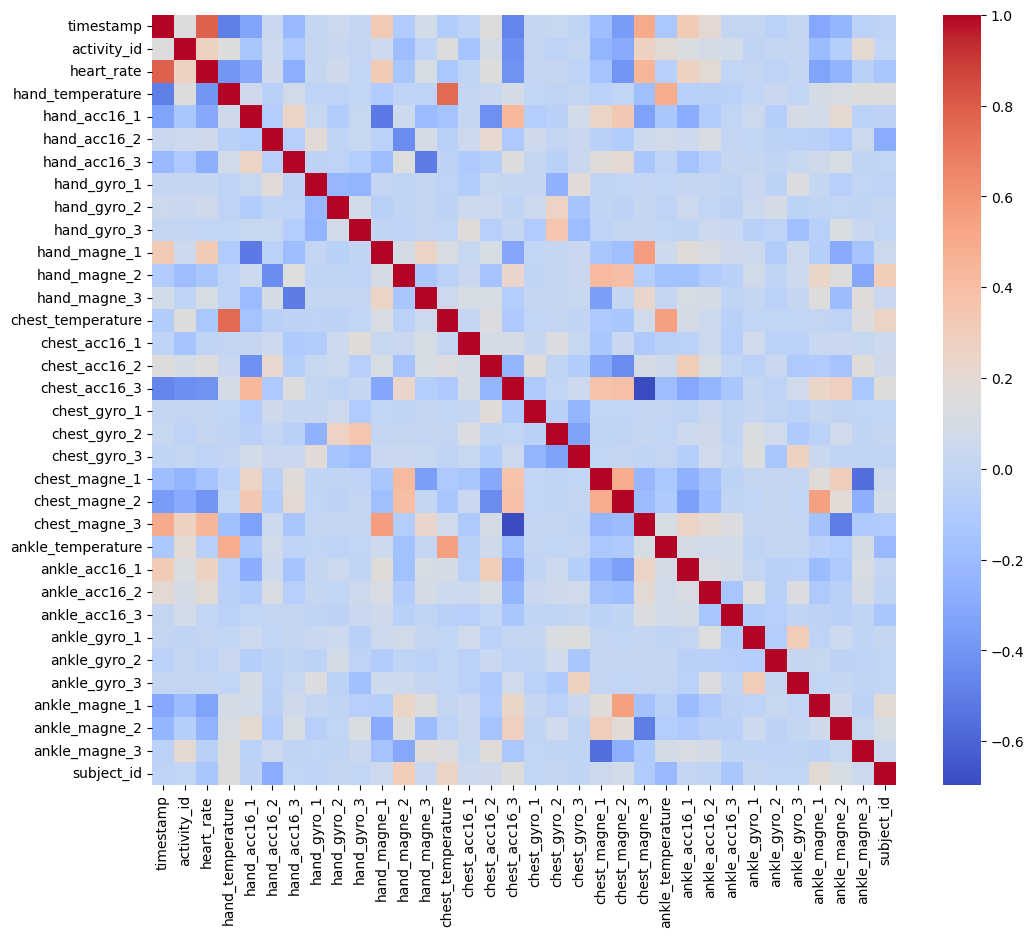

In [23]:
# Generate correlation heatmap to analyze relationships between numerical features
plt.figure(figsize=(12,10)) 

sns.heatmap(dz.corr(),annot = False, cmap = "coolwarm", fmt = " .2f")
plt.show()

In the heatmap, it is observed that, hand temperature is more correlated with the chest than ankle temperature. Further, there is a positive correlation with heart_rate and ankle accelerometer.

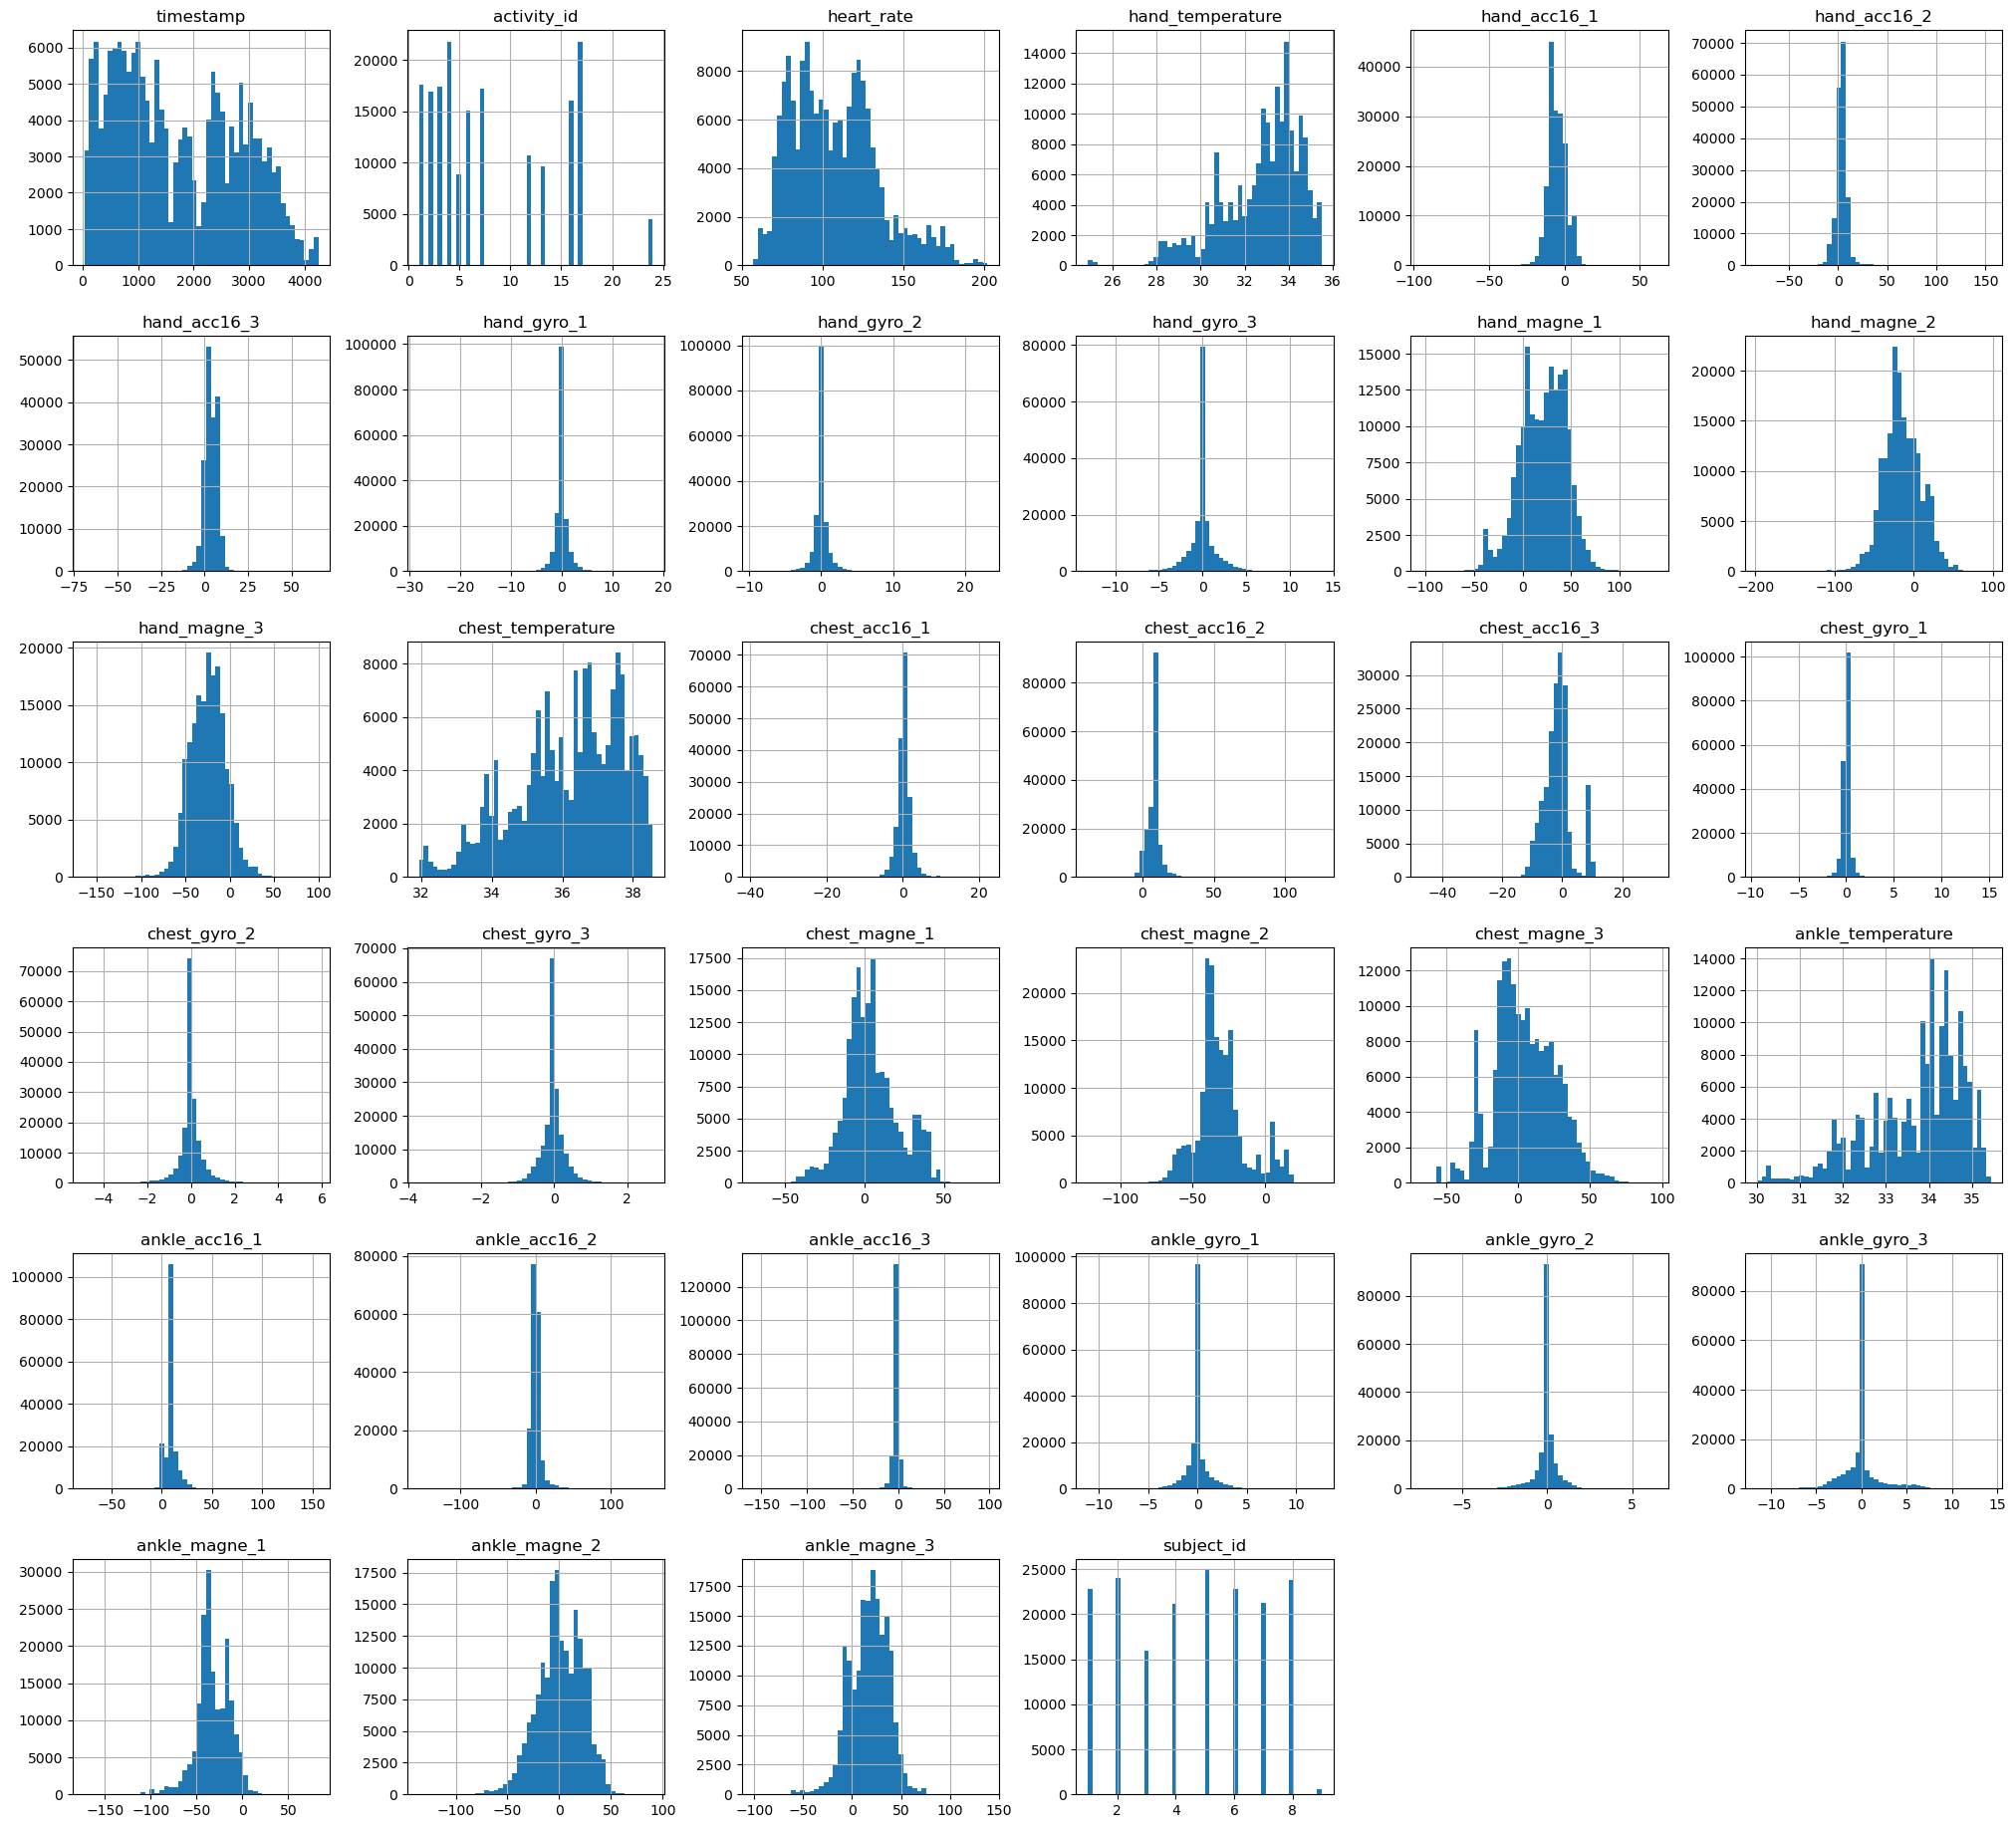

In [24]:
# Plot a histogram to find the frequency of each features
dz.hist(figsize = (25,23), bins = 50)
plt.show()

From the above histograms, it can be observed that majority of the attributes are not normally distributes. Furthermore, the gyroscope data most of the time shows that the body parts have minimal angular acceleration, close to zero. There is also an outlier in the hand temperature data.

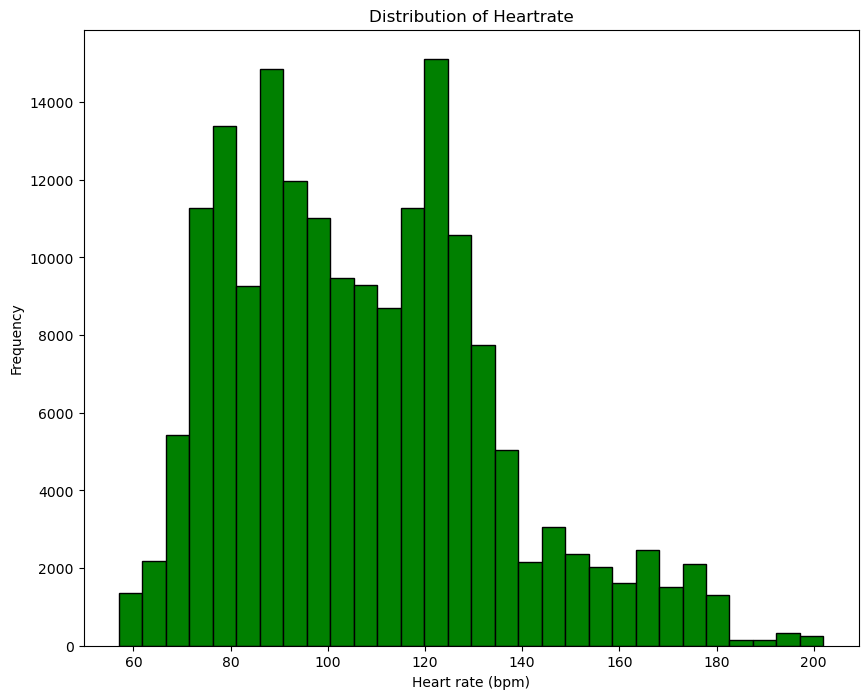

In [25]:
# Histogram of Heart Rate
plt.figure(figsize=(10, 8))
plt.hist(dz['heart_rate'], bins=30, color='green', edgecolor='black')
plt.title('Distribution of Heartrate')
plt.xlabel('Heart rate (bpm)')
plt.ylabel('Frequency')
plt.show()

From the histogram, it is observed that, many of the recorded observations fall within the 80-140 beats per minute range, indicating a slightly skewed distribution to the right. This suggests that the physical activities observed commonly led to a heart rate within this range.

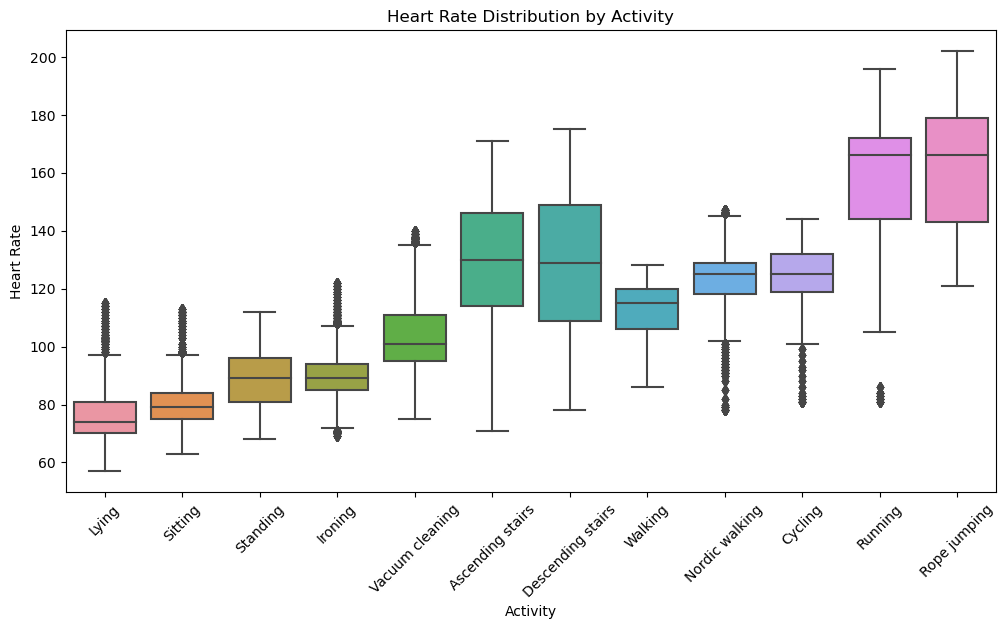

In [26]:
# Plotting a box plot between Heart rate and Chest temperature
plt.figure(figsize=(12, 6))

sns.boxplot(x='activity', y='heart_rate', data=df)

# Set labels and title
plt.xlabel('Activity')
plt.ylabel('Heart Rate')
plt.title('Heart Rate Distribution by Activity')
plt.xticks(rotation=45)

# Show the plot
plt.show()

The box plot reveals a clear intensity pattern in heart rate across activities, where low-intensity activities such as lying and sitting exhibit the lowest median heart rates (around 70–80 bpm) with minimal variation, while moderate activities like walking, ironing, and vacuum cleaning show higher heart rates (approximately 90–120 bpm) with a wider spread. In contrast, high-intensity activities such as running and rope jumping display the highest heart rates (around 150–180+ bpm), indicating significant physical exertion. Additionally, activities like ascending and descending stairs demonstrate greater variability, suggesting differences in effort levels among individuals. The presence of outliers across several activities further indicates occasional unusual heart rate fluctuations, likely due to individual physiological differences or varying activity intensity.

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


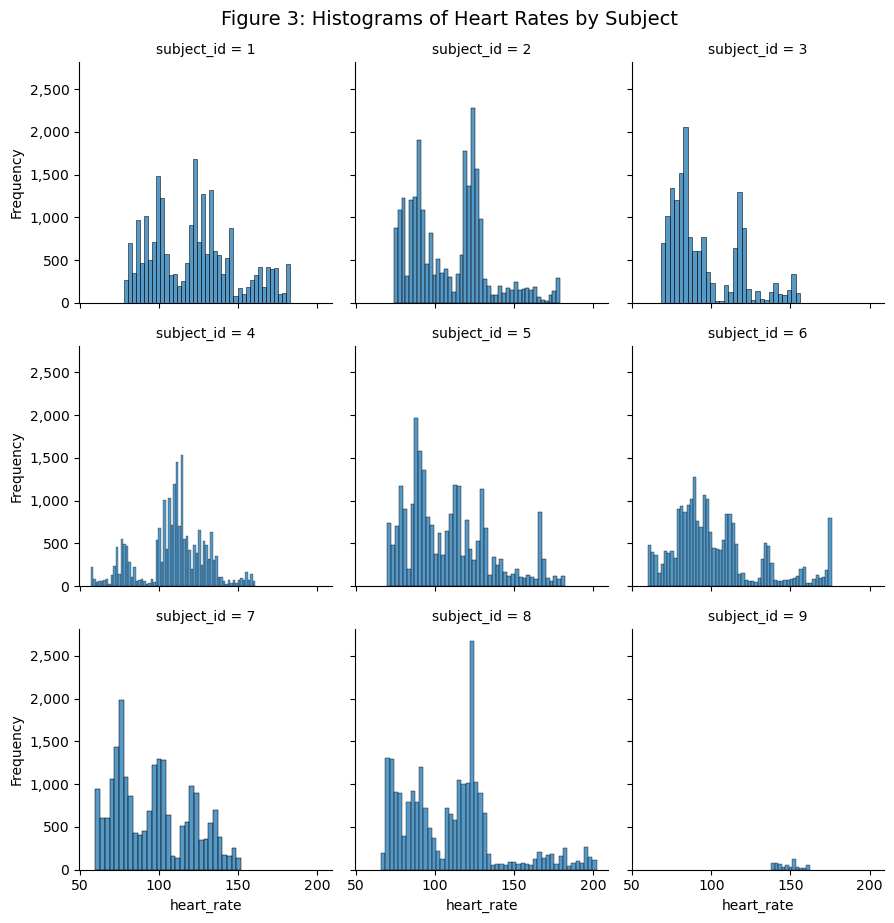

In [27]:
import matplotlib.ticker as ticker
g=sns.FacetGrid(dz[['subject_id','heart_rate']],col='subject_id',col_wrap=3)
g.map(sns.histplot,"heart_rate");
g.set_axis_labels("heart_rate","Frequency")

g.fig.suptitle('Figure 3: Histograms of Heart Rates by Subject',x=0.5,y=1.02,fontsize=14)

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f'{y:,.0f}'.format(y)))

After observing the above histogram, we get that the frequency of heart rate for subject_id 9 is less when compared with other subjects. This may due to the less participation of subject 9 in the activities.

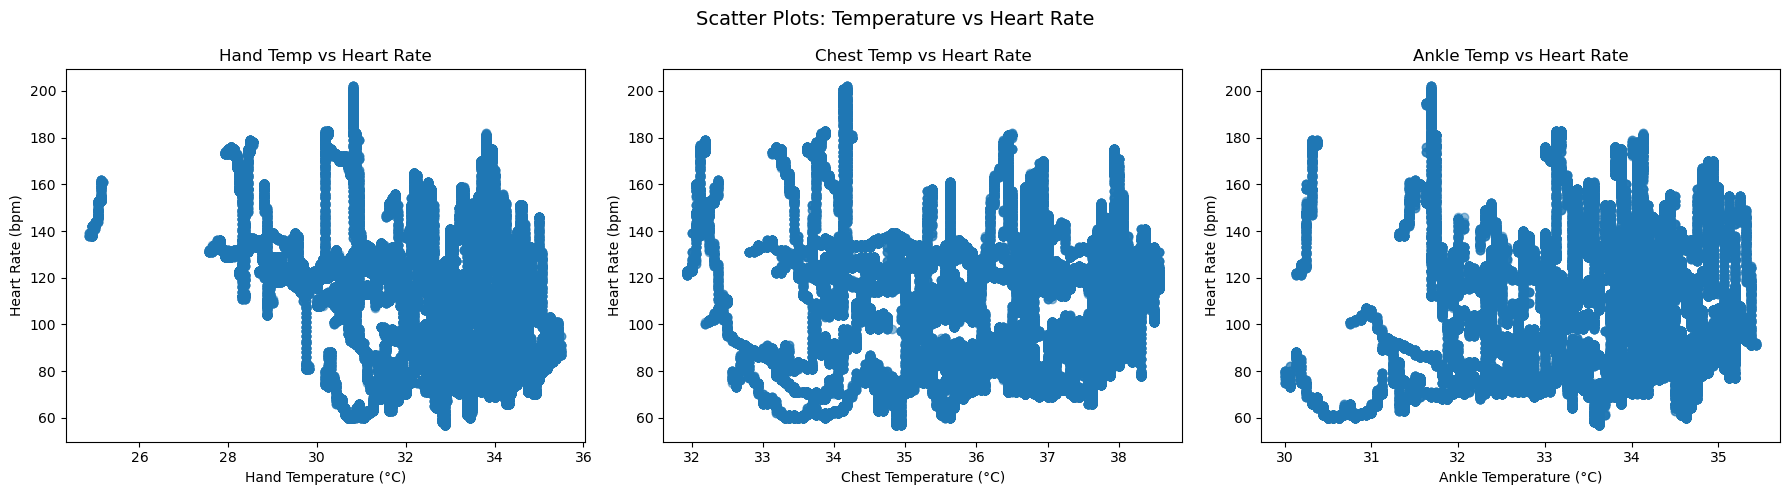

In [28]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hand Temperature vs Heart Rate
axes[0].scatter(df['hand_temperature'], df['heart_rate'], alpha=0.5)
axes[0].set_title('Hand Temp vs Heart Rate')
axes[0].set_xlabel('Hand Temperature (°C)')
axes[0].set_ylabel('Heart Rate (bpm)')

# Plot 2: Chest Temperature vs Heart Rate
axes[1].scatter(df['chest_temperature'], df['heart_rate'], alpha=0.5)
axes[1].set_title('Chest Temp vs Heart Rate')
axes[1].set_xlabel('Chest Temperature (°C)')
axes[1].set_ylabel('Heart Rate (bpm)')

# Plot 3: Ankle Temperature vs Heart Rate
axes[2].scatter(df['ankle_temperature'], df['heart_rate'], alpha=0.5)
axes[2].set_title('Ankle Temp vs Heart Rate')
axes[2].set_xlabel('Ankle Temperature (°C)')
axes[2].set_ylabel('Heart Rate (bpm)')

# Main title
fig.suptitle('Scatter Plots: Temperature vs Heart Rate', fontsize=14)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

The combined scatter plots illustrate the relationship between hand, chest, and ankle temperatures with heart rate. Across all three plots, the data points are widely dispersed, indicating no clear linear or non-linear relationship between temperature and heart rate.

For similar temperature values, heart rate varies significantly, suggesting that temperature alone is not a strong predictor of heart rate. This pattern is consistent across all sensor locations (hand, chest, and ankle), reinforcing the observation that heart rate is more influenced by the intensity of physical activity rather than body temperature.

Additionally, while temperature values remain within a relatively narrow range, heart rate exhibits a wide distribution, further highlighting its dynamic nature. Overall, the analysis confirms that temperature features have limited predictive power for heart rate and should be combined with other variables for effective activity recognition.


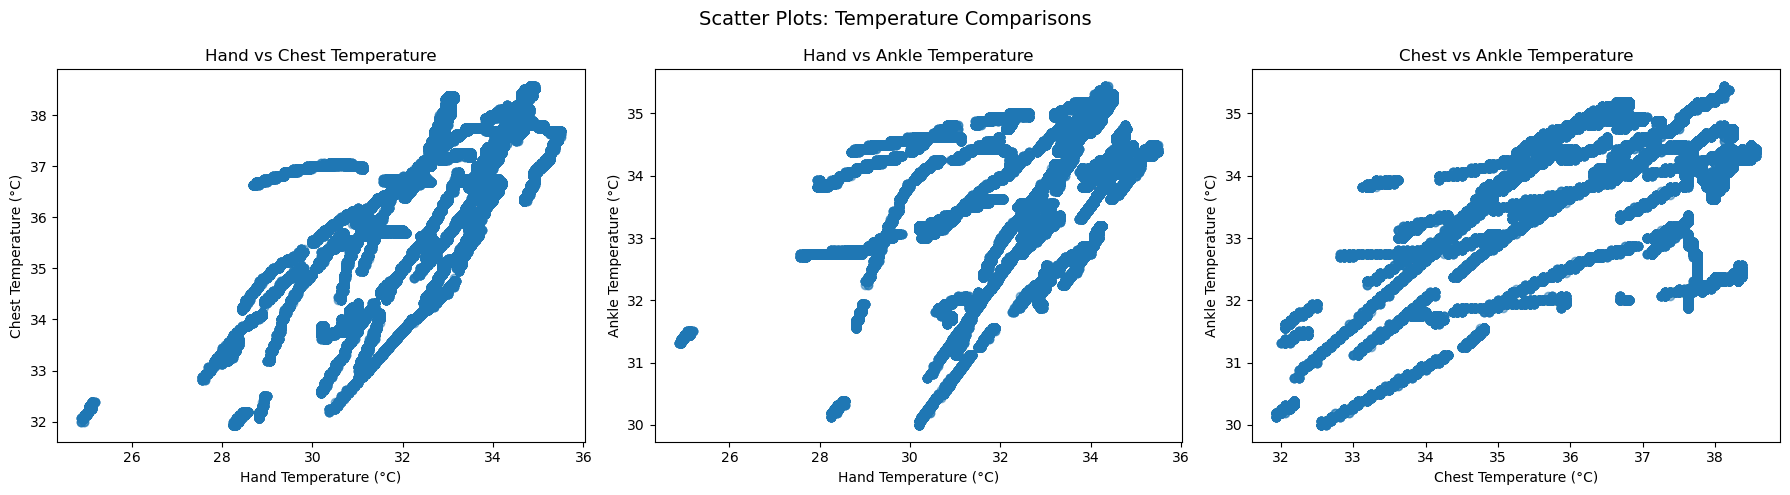

In [29]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hand vs Chest
axes[0].scatter(df['hand_temperature'], df['chest_temperature'], alpha=0.5)
axes[0].set_title('Hand vs Chest Temperature')
axes[0].set_xlabel('Hand Temperature (°C)')
axes[0].set_ylabel('Chest Temperature (°C)')

# Plot 2: Hand vs Ankle
axes[1].scatter(df['hand_temperature'], df['ankle_temperature'], alpha=0.5)
axes[1].set_title('Hand vs Ankle Temperature')
axes[1].set_xlabel('Hand Temperature (°C)')
axes[1].set_ylabel('Ankle Temperature (°C)')

# Plot 3: Chest vs Ankle
axes[2].scatter(df['chest_temperature'], df['ankle_temperature'], alpha=0.5)
axes[2].set_title('Chest vs Ankle Temperature')
axes[2].set_xlabel('Chest Temperature (°C)')
axes[2].set_ylabel('Ankle Temperature (°C)')

# Main title
fig.suptitle('Scatter Plots: Temperature Comparisons', fontsize=14)


# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

The scatter plots comparing hand, chest, and ankle temperatures demonstrate a strong positive correlation across all sensor locations. As the temperature in one region increases, the temperatures in the other regions tend to increase proportionally.

Among the comparisons, hand and chest temperatures show the strongest linear relationship, indicating consistent thermal behavior in the upper body. The relationships involving ankle temperature also exhibit positive trends, though with slightly more variability, likely due to peripheral differences in heat distribution.

Overall, the analysis confirms that body temperatures across different sensor locations are highly correlated and follow consistent patterns, making them reliable indicators of overall body thermal state.


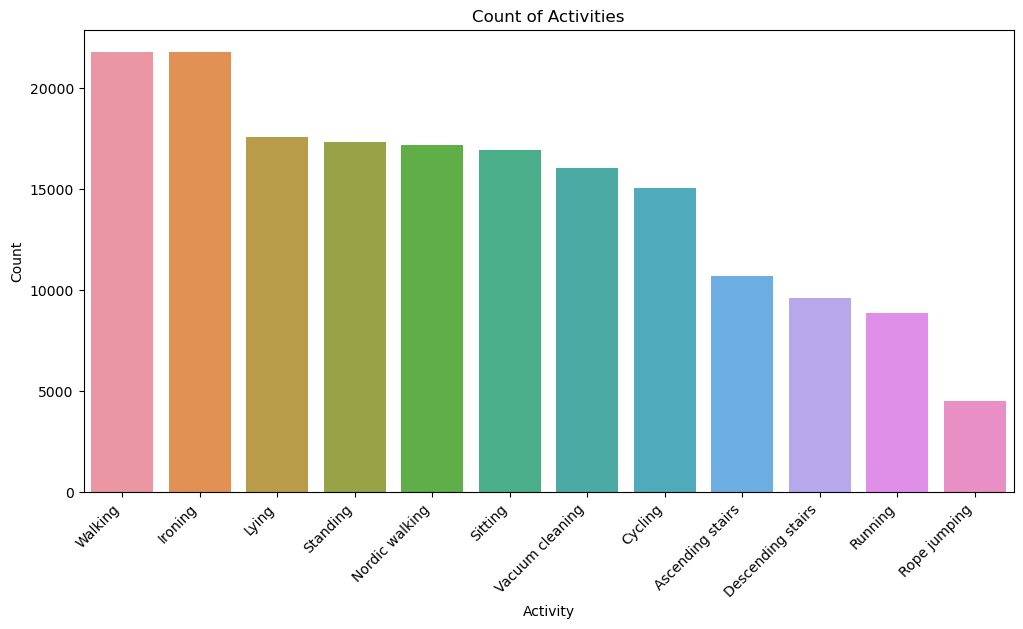

In [30]:
# Count Plot of Activities
plt.figure(figsize=(12, 6))
sns.countplot(x='activity', data=df, order=df['activity'].value_counts().index)
plt.title('Count of Activities')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

The bar shows how many times each activity occurs. Interestingly, the most common activity is walking and ironing, whereas the least is running and rope jumping.

### EDA Notes:
Correlation analysis revealed strong relationships between temperature readings across different body locations. Histograms indicated that most features are not normally distributed, and gyroscope readings often remain close to zero, indicating minimal angular motion in many activities.

Heart rate distribution analysis showed that most values fall within the range of 80–140 bpm, reflecting moderate to high physical activity levels.

Further analysis demonstrated that:

1. Heart rate increases significantly during high-intensity activities such as running and rope jumping.
2. Moderate increases are observed during activities like walking and stair climbing.
3. Minimal variation is seen during sedentary activities such as sitting and lying down.

These findings highlight meaningful relationships between physiological and motion-based features.

#  Modelling

The objective of the modelling phase is to classify human activities based on sensor data. For this, we need to create a model evaluate the capability of predicting the specific activity each subject is engaged in using the provided sensor data.

## PCA with Logistic regression model

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [32]:
# Initialise PCA
pca = PCA()

# Correct train-test split (IMPORTANT FIX)
X = dz.drop('activity_id', axis=1)
y = dz['activity_id']

x_train_, x_test_, y_train_, y_test_ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the logistic regression model
logistic_reg = LogisticRegression(max_iter=1000)
logistic_reg.fit(x_train_, y_train_)

# Predict on test set
y_pred_lr_ = logistic_reg.predict(x_test_)

# Metrics
accuracy = accuracy_score(y_test_, y_pred_lr_)
error = 1 - accuracy
precision = precision_score(y_test_, y_pred_lr_, average='weighted')
r_score = recall_score(y_test_, y_pred_lr_, average='weighted')
f1 = f1_score(y_test_, y_pred_lr_, average='weighted')

# Print results
print("Accuracy: ", accuracy)
print("Error: ", error)
print("Precision:", precision)
print("Recall:", r_score)
print("F1:", f1)

Accuracy:  0.8755707119102644
Error:  0.12442928808973563
Precision: 0.8713759316990531
Recall: 0.8755707119102644
F1: 0.8723564029800167


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model demonstrates strong overall performance in classifying physical activities, achieving an accuracy of 87.56%, which indicates that the model correctly predicts the activity in the majority of cases. The corresponding error rate of 12.44% suggests a relatively low level of misclassification.

The model’s precision score of 0.871 reflects its ability to make accurate positive predictions, while the recall score of 0.876 indicates that it effectively identifies most of the actual activity instances. Additionally, the F1-score of 0.872 provides a balanced measure of precision and recall, confirming that the model maintains consistent performance across different classes.

In [33]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test_, y_pred_lr_))


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.98      0.99      3520
           2       0.95      0.97      0.96      3386
           3       0.93      0.92      0.93      3470
           4       0.87      0.93      0.90      4357
           5       0.76      0.68      0.72      1777
           6       0.93      0.94      0.94      3009
           7       0.82      0.89      0.85      3440
          12       0.74      0.68      0.71      2142
          13       0.74      0.61      0.67      1918
          16       0.89      0.89      0.89      3206
          17       0.90      0.95      0.93      4354
          24       0.49      0.39      0.43       903

    accuracy                           0.88     35482
   macro avg       0.83      0.82      0.83     35482
weighted avg       0.87      0.88      0.87     35482



The classification report shows that the Logistic Regression model performs well overall, achieving an accuracy of approximately 88%, indicating strong predictive capability across most activity classes.

The model demonstrates excellent performance for activities such as lying (1), sitting (2), and standing (3), with precision and recall values close to 0.95–0.99, suggesting that these activities are easily distinguishable due to their stable and less complex motion patterns.

For moderate activities like walking (4), cycling (6), and ironing (17), the model maintains good performance, with F1-scores generally above 0.85, indicating reliable classification despite slightly increased variability in movement.

However, the model shows reduced performance for more complex or similar activities such as running (5), ascending/descending stairs (12, 13), and Nordic walking (7). These activities have lower precision and recall values, likely due to overlapping motion patterns and similarities in sensor readings.

The weakest performance is observed for rope jumping (24), with a low F1-score of 0.43, indicating difficulty in correctly identifying this activity. This may be due to limited data samples (low support) and high variability in movement.

The weighted average F1-score of 0.87 confirms that the model performs consistently well across all classes, taking into account class imbalance.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# Create pipeline (scaling + model together)
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

# Cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation Accuracy:", cv_scores.mean())

Cross-validation Accuracy: 0.7241892182229106


The cross-validation accuracy of 72.42% indicates that the model maintains reasonably consistent performance across different data splits, though it is lower than the test accuracy, suggesting slight overfitting or variability in generalisation.

## PCA with Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Selecting features and target variable
features = df.drop(['activity', 'activity_id'], axis=1)  # Excluding activity and activity_id
target = df['activity']

In [36]:
# Feature engineering using PCA
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [37]:
# Apply PCA
pca = PCA(n_components=0.95)  # Choose the number of components to retain 95% of variance
features_pca = pca.fit_transform(scaled_features)

In [38]:
# Split the PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    features_pca, target, test_size=0.2, random_state=42, stratify=target
)

In [39]:
# Train Random Forest
rf_model_pca = RandomForestClassifier(random_state=42)
rf_model_pca.fit(X_train_pca, y_train_pca)

# Predictions
rf_predictions_pca = rf_model_pca.predict(X_test_pca)

In [40]:
# Evaluation Metrics for Random Forest with PCA
print("Random Forest Metrics with PCA:")
print("Accuracy:", accuracy_score(y_test_pca, rf_predictions_pca))
print("Error:", 1 - accuracy_score(y_test_pca, rf_predictions_pca))
print("Precision:", precision_score(y_test_pca, rf_predictions_pca, average='weighted'))
print("Recall:", recall_score(y_test_pca, rf_predictions_pca, average='weighted'))
print("F1 Score:", f1_score(y_test_pca, rf_predictions_pca, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test_pca, rf_predictions_pca))

Random Forest Metrics with PCA:
Accuracy: 0.9640944704357138
Error: 0.035905529564286165
Precision: 0.9641939704474233
Recall: 0.9640944704357138
F1 Score: 0.9638253664228026

Classification Report:
                   precision    recall  f1-score   support

 Ascending stairs       0.90      0.86      0.88      2142
          Cycling       0.99      0.99      0.99      3009
Descending stairs       0.94      0.83      0.88      1918
          Ironing       0.97      0.99      0.98      4354
            Lying       1.00      0.99      1.00      3520
   Nordic walking       0.96      0.98      0.97      3440
     Rope jumping       1.00      0.95      0.97       903
          Running       0.99      0.99      0.99      1777
          Sitting       1.00      0.99      0.99      3386
         Standing       0.99      0.97      0.98      3470
  Vacuum cleaning       0.93      0.95      0.94      3206
          Walking       0.93      0.97      0.95      4357

         accuracy               

The Random Forest model combined with PCA demonstrates excellent performance, achieving an overall accuracy of 96.40%, indicating that the model correctly classifies the vast majority of activity instances with very low error (3.59%). The precision, recall, and F1-score values are all consistently high (around 0.96), showing that the model performs reliably across different classes without significant bias.

Looking at individual activities, the model performs exceptionally well for most classes such as cycling, lying, sitting, standing, and running, where precision and recall values are close to 1.00, indicating near-perfect classification. Activities like ironing, Nordic walking, and vacuum cleaning also show strong performance with high F1-scores above 0.94.

However, slightly lower performance is observed in activities such as ascending stairs and descending stairs, where recall values are relatively lower (around 0.83–0.86), suggesting some misclassification due to similarity in movement patterns. Despite this, the model still maintains strong overall performance for these activities.

The macro and weighted averages (0.96) confirm that the model generalizes well across all activity classes, effectively handling class imbalance and variability in the dataset.

Intersection occurs at component: 22


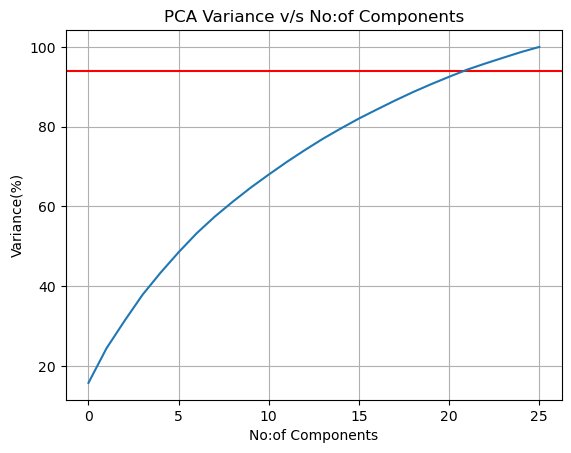

In [46]:
# Visualisations for PCA Variance v/s the number of components
pca = PCA()

# Fit the train data
pca.fit(X_train_pca)
var= pca.explained_variance_ratio_ # explains how much variance is captured by each components

# Cumulative sum explained variance ratio
var_1=np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)

print("Intersection occurs at component:", np.where(var_1 >= 94)[0][0] + 1)

# Plot PCA Variance v/s No:of Components
plt.title("PCA Variance v/s No:of Components")
plt.ylabel("Variance(%)")
plt.xlabel("No:of Components")
l = plt.axhline(94, color="red")

# Plot the graph
plt.plot(var_1)
plt.grid()

The PCA variance plot illustrates how much information (variance) is retained as the number of principal components increases. The curve shows a rapid rise initially, indicating that the first few components capture a significant portion of the dataset’s variance. As more components are added, the rate of increase gradually slows down, demonstrating diminishing returns.

From the graph, it is observed that 22 components are sufficient to capture around 94% of the total variance, as indicated by the intersection with the red reference line. This suggests that the original high-dimensional dataset can be effectively reduced to a smaller set of features without losing much important information.

# Conclusion

This project successfully demonstrates the application of machine learning techniques for human activity recognition using IMU and heart rate data. Through comprehensive data preprocessing, exploratory analysis, and model development, meaningful patterns were identified linking physiological responses and motion-based sensor readings to different physical activities.

The exploratory data analysis revealed that heart rate is strongly influenced by activity intensity, while temperature features showed limited predictive power individually but maintained strong correlations across body locations. These insights highlight the importance of combining multiple sensor modalities for effective activity classification.

Among the models evaluated, Logistic Regression achieved a solid baseline performance with an accuracy of approximately 87%, but showed limitations in handling complex and overlapping activity patterns. In contrast, the Random Forest model combined with PCA significantly outperformed it, achieving an accuracy of 96%, demonstrating its ability to capture non-linear relationships and handle high-dimensional sensor data effectively.

The PCA analysis further confirmed that the dataset can be reduced to 22 principal components while retaining approximately 94% of the total variance, enabling efficient dimensionality reduction without substantial information loss.

Overall, this study highlights the potential of combining wearable sensor data with machine learning techniques to build accurate and reliable activity recognition systems. The results indicate that ensemble models, particularly Random Forest, are well-suited for this task and can serve as a strong foundation for real-world wearable technology applications.

# Action Plan

1. As the Random Forest model with PCA has already proven successful, it would be good to refining and fine-tuning its parameters in pursuit of even greater accuracy.
2. Create a method to consistently track the performance of our models and deliver frequent progress reports. By doing so, we can guarantee that our technology remains current and impactful, able to evolve with shifting user demands and technological innovations.

# Limitations and Future Improvements
While the project demonstrates strong performance in activity classification, certain limitations exist. The model may be influenced by subject-specific patterns, and feature scaling was not consistently applied across all models. Additionally, differences in cross-validation and test accuracy suggest potential overfitting.

Future improvements could include proper feature scaling, subject-independent validation, hyperparameter tuning, and real-time deployment considerations. These enhancements would improve the robustness and generalisability of the model in real-world applications.

# Reference

1. https://www.kaggle.com/code/kirankarthikeyan/physical-activity-monitoring-using-imu/notebook
2. http://archive.ics.uci.edu/ml/datasets/pamap2+physical+activity+monitoring
3. DSRM lab materials